In [1]:
# THIS does not use the electrode remapping - out of date
# more robust with auc for mutiple windows

import os
import mne
import numpy as np
import pandas as pd
from scipy.signal import correlate
from scipy.integrate import simps
from scipy.stats import wilcoxon

# -------------------------------------------
# Load files
direct = "C:/EEG_vicon_rest"
files = [os.path.join(direct, file) for file in os.listdir(direct) if file.endswith(".parquet")]
files = sorted(files)

# -------------------------------------------
# Setup
electrodes = ['Fp1', 'Fp2', 'Fpz', 'F3', 'F4', 'F7', 'F8', 'C3', 'C4', 'Cz',
 'O1', 'O2', 'Oz', 'P3', 'P4', 'Pz', 'Fz']

#electrodes = ['C3', 'C4', 'Cz', 'F3', 'F4', 'Fz', 'P3', 'P4', 'Oz']
fs = 200  # Hz
win_size = 400  # 1 seconds
step_size = 100 * fs  # 1 second


import numpy as np
from scipy.signal import correlate

def autocorrelation_zero_crossing(signal):
    signal = np.asarray(signal)
    if np.std(signal) == 0:
        return 0.0  # Constant signal
    signal = (signal - np.mean(signal)) / np.std(signal)
    acf = correlate(signal, signal, mode='full')[len(signal) - 1:] / len(signal)
    zero_cross = np.where(np.diff(np.sign(acf)))[0]
    zc_lag = zero_cross[0] if len(zero_cross) > 0 else len(signal) // 2
    return zc_lag

def zc_lag_over_windows(sig, win_size=200, step_size=100):
    zc_lags = []
    for start in range(0, len(sig) - win_size + 1, step_size):
        window = sig[start:start + win_size]
        if len(window) < win_size:
            continue
        zc_lag = autocorrelation_zero_crossing(window)
        if not np.isnan(zc_lag):
            zc_lags.append(zc_lag)
    return np.mean(zc_lags) if zc_lags else np.nan


def autocorrelation_auc(signal):
    signal = np.asarray(signal)
    if np.std(signal) == 0:
        return 0.0  # Constant signal
    signal = (signal - np.mean(signal)) / np.std(signal)
    acf = correlate(signal, signal, mode='full')[len(signal) - 1:] / len(signal)
    zero_cross = np.where(np.diff(np.sign(acf)))[0]
    zc_lag = zero_cross[0] if len(zero_cross) > 0 else len(signal) // 2
    if zc_lag < 2 or len(acf[:zc_lag]) < 2:
        return 0.0
    return simps(acf[:zc_lag])

def auc_over_windows(sig,win_size=400, step_size=100):
    aucs = []
    for start in range(0, len(sig) - win_size + 1, step_size):
        window = sig[start:start + win_size]
        if len(window) < win_size:
            continue
        auc = autocorrelation_auc(window)
        if not np.isnan(auc):
            aucs.append(auc)
    return np.mean(aucs) if aucs else np.nan





C:\Users\Peter\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
# -------------------------------------------
# Setup: Common electrode set (after mapping)
common_electrodes_base = [
    'C3', 'C4', 'Cz', 'F3', 'F4', 'F7', 'F8', 'Fp1', 'Fp2', 'Fpz',
    'Fz', 'O1', 'O2', 'Oz', 'P3', 'P4', 'P7', 'P8', 'Pz', 'T7', 'T8'
]
common_electrodes_base = [
    'C3', 'C4', 'Cz', 'F3', 'F4', 'F7', 'F8', 'Fp1', 'Fp2', 
    'Fz', 'O1', 'O2',  'P3', 'P4', 'P7', 'P8', 'Pz', 'T7', 'T8'
]

# Mapping for 10-20 to 10-10
electrode_map_10_20_to_10_10 = {
    'T3': 'T7',
    'T4': 'T8',
    'T5': 'P7',
    'T6': 'P8'
}

fs = 200  # Hz
win_size = 2 * fs
step_size = 1 * fs

# -------------------------------------------
# Collect per-subject AUCs
subject_rest_data = []
subject_block_data = []
subject_fix_data = []
valid_electrodes_global = set(common_electrodes_base)

for filename in files:
    print(f"📂 Processing: {os.path.basename(filename)}")
    df = pd.read_parquet(filename)

    # Detect and rename electrodes if needed
    columns = df.columns
    remapped_cols = {col: electrode_map_10_20_to_10_10[col]
                     for col in columns if col in electrode_map_10_20_to_10_10}
    df = df.rename(columns=remapped_cols)

    # Select electrodes that exist in the current file
    electrodes = [e for e in common_electrodes_base if e in df.columns]

    auc_rest = {}
    auc_block = {}
    auc_fix = {}
    valid_electrodes_all = None

    for i in range(1, 10):
        df_rest = df.query(f'PERIODE == "REST{i}"')
        df_block = df.query(f'BLOCK == {i}')
        df_fix = df.query(f'PERIODE == "preFIX{i}"')

        auc_rest_i = []
        auc_block_i = []
        auc_fix_i = []
        valid_electrodes = []

        for elec in electrodes:
            sig_rest = df_rest[elec].dropna().values[:3000]
            sig_block = df_block[elec].dropna().values[:3000]
            sig_fix = df_fix[elec].dropna().values[:3000]

            if len(sig_rest) < win_size or len(sig_block) < win_size or len(sig_fix) < win_size:
                print('⚠️ short signal:', elec)
                continue

            auc_r = auc_over_windows(sig_rest)
            auc_b = auc_over_windows(sig_block)
            auc_f = auc_over_windows(sig_fix)

            if np.isnan(auc_r) or np.isnan(auc_b) or np.isnan(auc_f):
                print('⚠️ NaN detected:', elec)
                continue

            auc_rest_i.append(auc_r)
            auc_block_i.append(auc_b)
            auc_fix_i.append(auc_f)
            valid_electrodes.append(elec)

        auc_rest[i] = auc_rest_i
        auc_block[i] = auc_block_i
        auc_fix[i] = auc_fix_i

        if valid_electrodes_all is None:
            valid_electrodes_all = set(valid_electrodes)
        else:
            valid_electrodes_all &= set(valid_electrodes)

    valid_electrodes_all = sorted(list(valid_electrodes_all))
    valid_electrodes_global &= set(valid_electrodes_all)

    rest_matrix = np.array([
        [auc_rest[b][valid_electrodes_all.index(e)] for b in range(1, 10)]
        for e in valid_electrodes_all
    ])
    block_matrix = np.array([
        [auc_block[b][valid_electrodes_all.index(e)] for b in range(1, 10)]
        for e in valid_electrodes_all
    ])
    fix_matrix = np.array([
        [auc_fix[b][valid_electrodes_all.index(e)] for b in range(1, 10)]
        for e in valid_electrodes_all
    ])

    subject_rest_data.append(rest_matrix)
    subject_block_data.append(block_matrix)
    subject_fix_data.append(fix_matrix)

# -------------------------------------------
# Harmonize across subjects (only keep electrodes valid for all)
valid_electrodes_global = sorted(list(valid_electrodes_global))
print(f"\n✅ Electrodes valid for ALL subjects: {valid_electrodes_global}")

n_subjects = len(subject_rest_data)
n_electrodes = len(valid_electrodes_global)

rest_all = np.stack([
    subj[[valid_electrodes_global.index(e) for e in valid_electrodes_global], :]
    for subj in subject_rest_data
])
block_all = np.stack([
    subj[[valid_electrodes_global.index(e) for e in valid_electrodes_global], :]
    for subj in subject_block_data
])
fix_all = np.stack([
    subj[[valid_electrodes_global.index(e) for e in valid_electrodes_global], :]
    for subj in subject_fix_data
])


📂 Processing: DF_SYNCHRO_EEG_RESTFIXBLOCK_Adrien.parquet
📂 Processing: DF_SYNCHRO_EEG_RESTFIXBLOCK_Ana.parquet
📂 Processing: DF_SYNCHRO_EEG_RESTFIXBLOCK_Antoine.parquet
📂 Processing: DF_SYNCHRO_EEG_RESTFIXBLOCK_Camila.parquet
📂 Processing: DF_SYNCHRO_EEG_RESTFIXBLOCK_Charlene.parquet
📂 Processing: DF_SYNCHRO_EEG_RESTFIXBLOCK_Denis.parquet
📂 Processing: DF_SYNCHRO_EEG_RESTFIXBLOCK_Denis2.parquet
📂 Processing: DF_SYNCHRO_EEG_RESTFIXBLOCK_Ko.parquet
📂 Processing: DF_SYNCHRO_EEG_RESTFIXBLOCK_Louise.parquet
📂 Processing: DF_SYNCHRO_EEG_RESTFIXBLOCK_Mael.parquet
📂 Processing: DF_SYNCHRO_EEG_RESTFIXBLOCK_Patrice.parquet
📂 Processing: DF_SYNCHRO_EEG_RESTFIXBLOCK_Pauline.parquet
📂 Processing: DF_SYNCHRO_EEG_RESTFIXBLOCK_Pierre.parquet
📂 Processing: DF_SYNCHRO_EEG_RESTFIXBLOCK_Sophie.parquet
📂 Processing: DF_SYNCHRO_EEG_RESTFIXBLOCK_Vincent.parquet
📂 Processing: DF_SYNCHRO_EEG_RESTFIXBLOCK_Yuki.parquet
📂 Processing: DF_SYNCHRO_EEG_RESTFIXBLOCK_Yuyang.parquet
📂 Processing: DF_SYNCHRO_EEG_RESTFIXB

In [45]:
df_block

,TIME,C3,C4,Cz,F3,F4,F7,F8,Fp1,Fp2,...,RZ,BLOCK,HV,RV,DISTANCE,LAG,MOUV,Motif,VHD,PERIODE
342827,1714.135,-2.800703,0.884814,-2.037386,-0.876290,1.300453,1.629865,3.150487,-1.497502,1.672246,...,563.893,9.0,5.086295,28.611187,141.207011,0.255,Rest-A,B9_1,None,BLOCK_9
342828,1714.140,1.925024,2.675644,-0.373332,3.723166,3.003172,-3.354271,2.731949,-1.849433,0.815161,...,563.977,9.0,3.273469,35.647721,141.161737,0.255,Rest-A,B9_1,None,BLOCK_9
342829,1714.145,3.099916,5.065383,1.562296,4.441787,3.853227,-4.171427,2.129961,-1.695302,-0.587298,...,564.076,9.0,2.357626,41.857377,141.067947,0.255,Rest-A,B9_1,None,BLOCK_9
342830,1714.150,-0.012284,5.366969,2.705234,1.412188,3.448138,-0.435410,1.865088,-0.324336,-0.892382,...,564.224,9.0,0.721388,51.389104,140.957197,0.255,Rest-A,B9_1,None,BLOCK_9
342831,1714.155,-2.057102,2.183054,2.154658,-0.901470,1.713649,0.814746,1.404611,0.554872,0.114618,...,564.393,9.0,2.929573,61.653873,140.807974,0.255,Rest-A,B9_1,None,BLOCK_9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
359570,1797.850,-4.241147,-4.448228,-8.665260,-4.531625,-2.934156,4.529309,3.572538,-1.153302,3.197272,...,563.861,9.0,392.051083,48.476386,187.625797,0.000,None,None,None,BLOCK_9
359571,1797.855,-5.018271,-5.913363,-9.040418,-6.844919,-3.985969,3.239056,1.314151,1.136417,3.023957,...,563.766,9.0,391.389965,49.787549,186.694531,0.000,None,None,None,BLOCK_9
359572,1797.860,-4.530092,-4.487012,-8.342162,-7.144937,-3.917838,0.400412,-0.031583,2.219756,2.197896,...,563.686,9.0,393.192747,45.318429,185.785292,0.000,None,None,None,BLOCK_9
359573,1797.865,-2.640158,-2.118171,-6.983431,-4.632272,-2.458842,-1.000215,0.704035,1.438915,1.611827,...,563.599,9.0,389.363602,43.776249,184.905359,0.000,None,None,None,BLOCK_9


In [3]:
# -------------------------------------------
# Group-level statistics
rest_mean_per_elec = np.mean(rest_all, axis=(0, 2))
block_mean_per_elec = np.mean(block_all, axis=(0, 2))
fix_mean_per_elec = np.mean(fix_all, axis=(0, 2))
diff_mean_per_elec = block_mean_per_elec - rest_mean_per_elec

p_values = []
significant = []

for e in range(n_electrodes):
    rest_per_subj = rest_all[:, e, :].mean(axis=1)
    block_per_subj = block_all[:, e, :].mean(axis=1)
    fix_per_subj = fix_all[:, e, :].mean(axis=1)
    stat, p = wilcoxon(block_per_subj, rest_per_subj)
    p_values.append(p)
    significant.append(p < 0.05)

# -------------------------------------------
# Summary table
print("\n📊 Group-level Summary Table:")
print(f"{'Electrode':<8} {'FIX_mean':>10} {'REST_mean':>10} {'BLOCK_mean':>12} {'Diff':>10} {'p-value':>10} {'Signif.':>8}")
print("-" * 60)

for e, f, r, b, d, p, s in zip(valid_electrodes_global,  fix_mean_per_elec, rest_mean_per_elec, block_mean_per_elec, diff_mean_per_elec, p_values, significant):
    star = '*' if s else ''
    print(f"{e:<8}  {f:10.4f}{r:10.4f} {b:12.4f} {d:10.4f} {p:10.4f} {star:>8}")


📊 Group-level Summary Table:
Electrode   FIX_mean  REST_mean   BLOCK_mean       Diff    p-value  Signif.
------------------------------------------------------------
C3            8.0223    9.3216      10.9605     1.6389     0.0539         
C4            7.3574    9.2055      10.7763     1.5708     0.0539         
Cz            8.4112    8.9277      10.8347     1.9069     0.0208        *
F3            8.3871   10.6722      11.6258     0.9535     0.2462         
F4            8.1836   10.1819      11.0277     0.8458     0.1815         
F7            8.9649   13.0710      14.0234     0.9523     0.3927         
F8            8.7085   11.9825      13.6876     1.7051     0.1815         
Fp1           9.9806   13.1020      14.9102     1.8082     0.1187         
Fp2           9.8630   13.3144      14.9985     1.6840     0.0987         
Fz            8.7417    9.5653      10.8756     1.3103     0.1187         
O1            8.6163    9.8271      11.9943     2.1672     0.0208        *
O2      

In [4]:
print(df_rest.shape[0])
print(df_rest[elec].dropna().shape[0])
print(df_block.shape[0])
print(df_block[elec].dropna().shape[0])

6000
6000
16748
16748


C:\Users\Peter\AppData\Local\Temp\ipykernel_13292\1406953238.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])


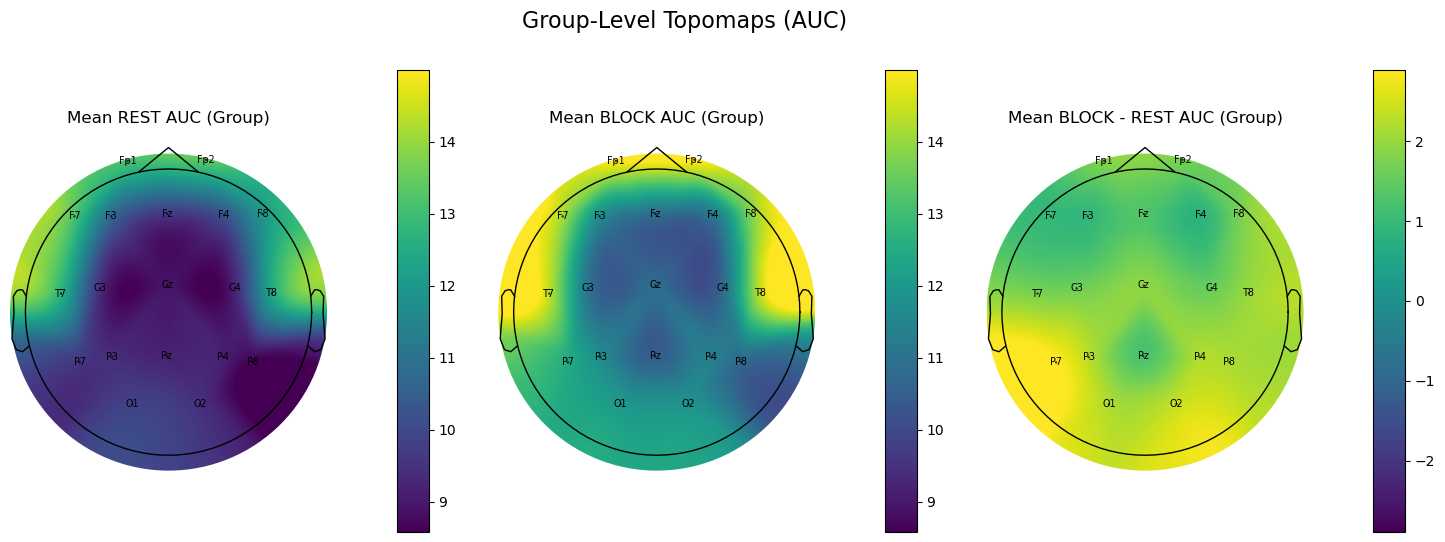

In [5]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
# -------------------------------------------

# Create MNE info and layout
info = mne.create_info(ch_names=valid_electrodes_all, sfreq=1000, ch_types='eeg')
montage = mne.channels.make_standard_montage('standard_1020')
info.set_montage(montage)

layout = mne.channels.make_eeg_layout(info)
pos = layout.pos[:, :2]

# Shared colormap limits for consistent scaling
all_vals = np.concatenate([rest_mean_per_elec, block_mean_per_elec])
vmin = all_vals.min()
vmax = all_vals.max()

# For difference map (BLOCK - REST), use symmetric scale centered at 0
diff_abs_max = np.max(np.abs(diff_mean_per_elec))
vlim_diff = (-diff_abs_max, diff_abs_max)

# -------------------------------------------
# Group Topomaps with shared color scales
titles = ['Mean REST AUC (Group)', 'Mean BLOCK AUC (Group)', 'Mean BLOCK - REST AUC (Group)']
data_list = [rest_mean_per_elec, block_mean_per_elec, diff_mean_per_elec]
vlims = [(vmin, vmax), (vmin, vmax), vlim_diff]

fig = plt.figure(figsize=(18, 6))
gs = gridspec.GridSpec(1, 6, width_ratios=[10, 1, 10, 1, 10, 1], wspace=0.4)

for i in range(3):
    ax = fig.add_subplot(gs[0, i*2])
    cax = fig.add_subplot(gs[0, i*2 + 1])

    im, _ = mne.viz.plot_topomap(
        data_list[i],
        info,
        axes=ax,
        show=False,
        vlim=vlims[i],  # ✅ correct keyword here
        names=valid_electrodes_global,
        contours=0,
        cmap='viridis'#'RdBu_r'  # <-- add this line to change colormap

    )
    ax.set_title(titles[i])
    plt.colorbar(im, cax=cax)

plt.suptitle("Group-Level Topomaps (AUC)", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


C:\Users\Peter\AppData\Local\Temp\ipykernel_13292\359200699.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])


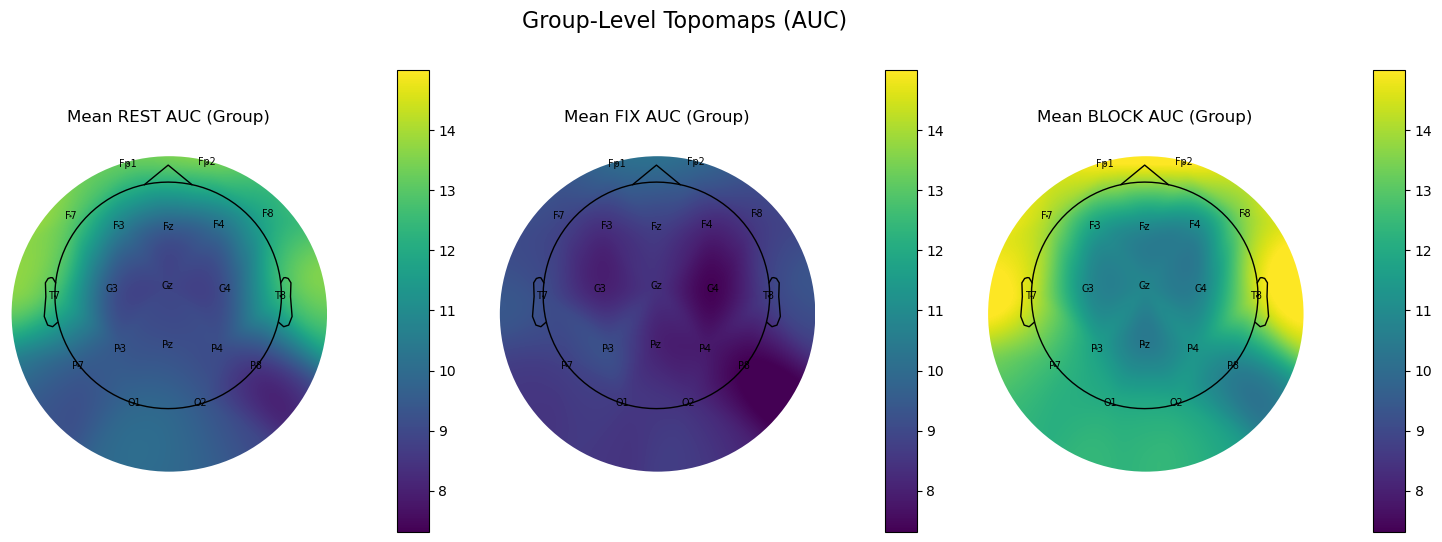

In [6]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
# -------------------------------------------

# Create MNE info and layout
info = mne.create_info(ch_names=valid_electrodes_all, sfreq=200, ch_types='eeg')
montage = mne.channels.make_standard_montage('standard_1020')
info.set_montage(montage)

layout = mne.channels.make_eeg_layout(info)
pos = layout.pos[:, :2]

# Shared colormap limits for consistent scaling
all_vals = np.concatenate([rest_mean_per_elec, block_mean_per_elec, fix_mean_per_elec])
vmin = all_vals.min()
vmax = all_vals.max()


# -------------------------------------------
# Group Topomaps with shared color scales
titles = ['Mean REST AUC (Group)', 'Mean FIX AUC (Group)', 'Mean BLOCK AUC (Group)']
data_list = [rest_mean_per_elec, fix_mean_per_elec, block_mean_per_elec]
vlims = [(vmin, vmax), (vmin, vmax), (vmin, vmax)]

fig = plt.figure(figsize=(18, 6))
gs = gridspec.GridSpec(1, 6, width_ratios=[10, 1, 10, 1, 10, 1], wspace=0.4)

for i in range(3):
    ax = fig.add_subplot(gs[0, i*2])
    cax = fig.add_subplot(gs[0, i*2 + 1])

    im, _ = mne.viz.plot_topomap(
        data_list[i],
        info,
        axes=ax,
        show=False,
        vlim=vlims[i],  # ✅ correct keyword here
        names=valid_electrodes_global,
        contours=0,
        extrapolate='head',
        sphere='auto',
        cmap= "viridis"#'RdBu_r'  # <-- add this line to change colormap

    )
    ax.set_title(titles[i])
    plt.colorbar(im, cax=cax)

plt.suptitle("Group-Level Topomaps (AUC)", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


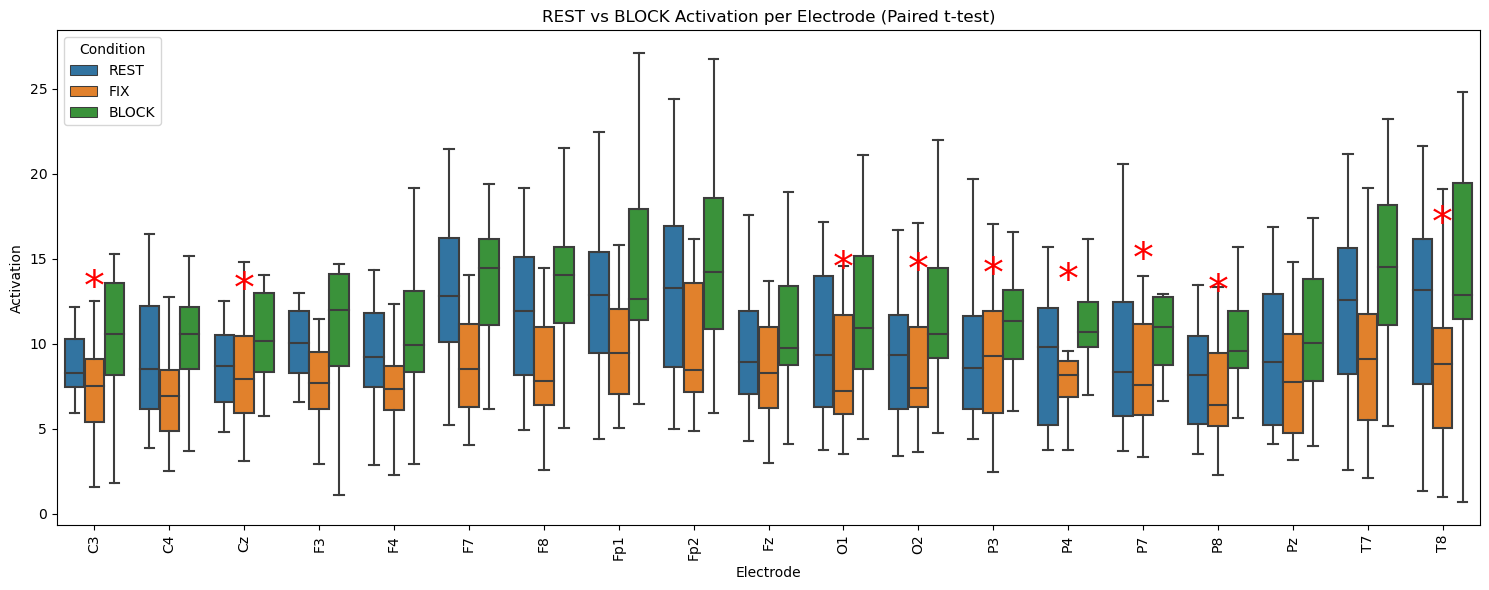

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_rel
from scipy.signal import correlate
from scipy.integrate import simps
import numpy as np
import pandas as pd

#sns.set(style="whitegrid")

# Assuming you already have these:
# - rest_all: shape (n_subjects, n_electrodes, n_timepoints)
# - fix_all:  same shape
# - block_all: same shape
# - electrodes: list of length n_electrodes with electrode names

n_electrodes = rest_all.shape[1]
p_values = []
significant = []

# Collect data
data = []
labels = []
electrode_ids = []

# For plotting stars
mean_activation = []

for e in range(n_electrodes):
    rest_per_subj = rest_all[:, e, :].mean(axis=1)
    fix_per_subj = fix_all[:, e, :].mean(axis=1)
    block_per_subj = block_all[:, e, :].mean(axis=1)

    # Store for plotting, using actual electrode names
    data.extend(rest_per_subj)
    labels.extend(['REST'] * len(rest_per_subj))
    electrode_ids.extend([electrodes[e]] * len(rest_per_subj))

    data.extend(fix_per_subj)
    labels.extend(['FIX'] * len(fix_per_subj))
    electrode_ids.extend([electrodes[e]] * len(fix_per_subj))

    data.extend(block_per_subj)
    labels.extend(['BLOCK'] * len(block_per_subj))
    electrode_ids.extend([electrodes[e]] * len(block_per_subj))

    # Paired t-test (BLOCK vs REST)
    stat, p = ttest_rel(block_per_subj, rest_per_subj)
    p_values.append(p)
    significant.append(p < 0.05)

    # For star plotting
    mean_activation.append(max(np.mean(rest_per_subj), np.mean(block_per_subj)))

# Create DataFrame for seaborn
df = pd.DataFrame({
    'Activation': data,
    'Condition': labels,
    'Electrode': electrode_ids
})

# Plot
plt.figure(figsize=(15, 6))
ax = sns.boxplot(data=df, x='Electrode', y='Activation', hue='Condition', showfliers=False)
plt.title('REST vs BLOCK Activation per Electrode (Paired t-test)')
plt.xticks(rotation=90)

# Add significance stars
for i, sig in enumerate(significant):
    if sig:
        y = mean_activation[i] + 0.1 * np.abs(mean_activation[i])  # small offset
        ax.text(i, y, '*', ha='center', va='bottom', color='red', fontsize=30)

plt.tight_layout()
plt.show()


In [8]:
for e in range(n_electrodes):
    rest_per_subj = rest_all[:, e, :].mean(axis=1)
    fix_per_subj = fix_all[:, e, :].mean(axis=1)
    block_per_subj = block_all[:, e, :].mean(axis=1)

    # Store for plotting
    data.extend(rest_per_subj)
    labels.extend(['REST'] * len(rest_per_subj))
    electrode_ids.extend([electrodes[e]] * len(rest_per_subj))

    data.extend(fix_per_subj)
    labels.extend(['FIX'] * len(fix_per_subj))
    electrode_ids.extend([electrodes[e]] * len(fix_per_subj))

    data.extend(block_per_subj)
    labels.extend(['BLOCK'] * len(block_per_subj))
    electrode_ids.extend([electrodes[e]] * len(block_per_subj))

    # Paired t-test
    stat, p = ttest_rel(block_per_subj, rest_per_subj)
    p_values.append(p)
    significant.append(p < 0.05)

    # For star plotting
    mean_activation.append(max(np.mean(rest_per_subj), np.mean(block_per_subj)))


In [9]:
electrode_names=electrodes

In [10]:
import pingouin as pg
import pandas as pd

# Format data as a long-format DataFrame
# Each row = (subject, electrode, condition, value)

n_subjects = rest_all.shape[0]
rows = []

for subj in range(n_subjects):
    for e in range(n_electrodes):
        rest_val = rest_all[subj, e, :].mean()
        block_val = block_all[subj, e, :].mean()
        fix_val = fix_all[subj, e, :].mean()
        rows.append([subj, electrode_names[e], 'REST', rest_val])
        rows.append([subj, electrode_names[e], 'FIX', fix_val])
        rows.append([subj, electrode_names[e], 'BLOCK', block_val])

df_anova = pd.DataFrame(rows, columns=['Subject', 'Electrode', 'Condition', 'Activation'])

# Run repeated-measures ANOVA
aov = pg.rm_anova(data=df_anova, dv='Activation', within=['Condition', 'Electrode'], subject='Subject', detailed=True)
print(aov)


                  Source           SS  ddof1  ddof2           MS          F  \
0              Condition  2334.518440      2     34  1167.259220  16.273046   
1              Electrode  1522.529011     18    306    84.584945   4.909668   
2  Condition * Electrode   320.333793     36    612     8.898161   3.217455   

          p-unc  p-GG-corr       ng2       eps  
0  1.101687e-05   0.000024  0.111806  0.911965  
1  1.001541e-09   0.000201  0.075868  0.330125  
2  2.889338e-09   0.013206  0.016979  0.126369  


C:\Users\Peter\anaconda3\lib\site-packages\outdated\utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.3, the latest is 0.5.5.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(
C:\Users\Peter\anaconda3\lib\site-packages\pingouin\distribution.py:515: UserWarning: Epsilon values might be innaccurate in two-way repeated measures design where each  factor has more than 2 levels. Please  double-check your results.
  warnings.warn(


In [11]:
import pandas as pd
import pingouin as pg

# Define your updated groups
group_1 = ['F3', 'F4', 'Fz']
group_2 = ['C3', 'C4', 'Cz']
group_3 = ['P3', 'P4', 'P7']
group_4 = ['O1', 'O2']

electrode_to_group = {}
for name in group_1:
    electrode_to_group[name] = 'Frontal'
for name in group_2:
    electrode_to_group[name] = 'Central'
for name in group_3:
    electrode_to_group[name] = 'Parietal'
for name in group_4:
    electrode_to_group[name] = 'Occipital'
# Build list of rows for DataFrame
rows = []
n_subjects = rest_all.shape[0]

for subj in range(n_subjects):
    for group in ['Frontal', 'Central', 'Parietal', 'Occipital']:
        # Find electrode indices belonging to this group
        group_inds = [i for i, name in enumerate(electrode_names) if name in electrode_to_group and electrode_to_group[name] == group]
        
        if not group_inds:
            continue  # skip if no matching electrodes

        rest_val = rest_all[subj, group_inds, :].mean()
        fix_val = fix_all[subj, group_inds, :].mean()
        block_val = block_all[subj, group_inds, :].mean()

        rows.append([subj, group, 'REST', rest_val])
        rows.append([subj, group, 'FIX', fix_val])
        rows.append([subj, group, 'BLOCK', block_val])

# Create long-form DataFrame
df = pd.DataFrame(rows, columns=['Subject', 'ElectrodeGroup', 'Condition', 'Activation'])

# Run repeated-measures ANOVA
aov = pg.rm_anova(
    data=df,
    dv='Activation',
    within=['Condition', 'ElectrodeGroup'],
    subject='Subject',
    detailed=True
)

print(aov)


                       Source          SS  ddof1  ddof2          MS  \
0                   Condition  345.314335      2     34  172.657167   
1              ElectrodeGroup   17.066775      3     51    5.688925   
2  Condition * ElectrodeGroup   11.715053      6    102    1.952509   

           F     p-unc  p-GG-corr       ng2       eps  
0  12.564615  0.000082   0.000097  0.101251  0.975030  
1   0.673481  0.572271   0.498611  0.005537  0.583892  
2   1.683955  0.132427   0.202824  0.003807  0.313291  


C:\Users\Peter\anaconda3\lib\site-packages\pingouin\distribution.py:515: UserWarning: Epsilon values might be innaccurate in two-way repeated measures design where each  factor has more than 2 levels. Please  double-check your results.
  warnings.warn(


In [12]:
for group in ['Frontal', 'Central', 'Parietal','Occipital']:
    group_rows = df[df['ElectrodeGroup'] == group]
    posthoc_group = pg.pairwise_tests(
        data=group_rows,
        dv='Activation',
        within='Condition',
        subject='Subject',
        parametric=True,
        padjust='fdr_bh'
    )
    print(f"\n--- {group} ---")
    # Print only relevant columns that exist
    available_cols = posthoc_group.columns
    cols_to_show = [col for col in ['A', 'B', 'T', 'dof', 'p-unc', 'p-corr', 'p-adjust'] if col in available_cols]
    print(posthoc_group[cols_to_show])



--- Frontal ---
       A     B         T   dof     p-unc    p-corr p-adjust
0  BLOCK   FIX  5.591575  17.0  0.000032  0.000097   fdr_bh
1  BLOCK  REST  1.495035  17.0  0.153237  0.153237   fdr_bh
2    FIX  REST -2.741394  17.0  0.013917  0.020875   fdr_bh

--- Central ---
       A     B         T   dof     p-unc    p-corr p-adjust
0  BLOCK   FIX  5.627890  17.0  0.000030  0.000090   fdr_bh
1  BLOCK  REST  2.536369  17.0  0.021299  0.031948   fdr_bh
2    FIX  REST -1.870957  17.0  0.078666  0.078666   fdr_bh

--- Parietal ---
       A     B         T   dof     p-unc    p-corr p-adjust
0  BLOCK   FIX  4.955105  17.0  0.000120  0.000361   fdr_bh
1  BLOCK  REST  3.628419  17.0  0.002077  0.003115   fdr_bh
2    FIX  REST -1.048815  17.0  0.308946  0.308946   fdr_bh

--- Occipital ---
       A     B         T   dof     p-unc    p-corr p-adjust
0  BLOCK   FIX  3.741217  17.0  0.001626  0.004877   fdr_bh
1  BLOCK  REST  2.863206  17.0  0.010769  0.016154   fdr_bh
2    FIX  REST -1.451656  17.

In [13]:
print(posthoc_group.columns)

Index(['Contrast', 'A', 'B', 'Paired', 'Parametric', 'T', 'dof', 'alternative',
       'p-unc', 'p-corr', 'p-adjust', 'BF10', 'hedges'],
      dtype='object')


C:\Users\Peter\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Peter\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Peter\anaconda3\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\Peter\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future vers

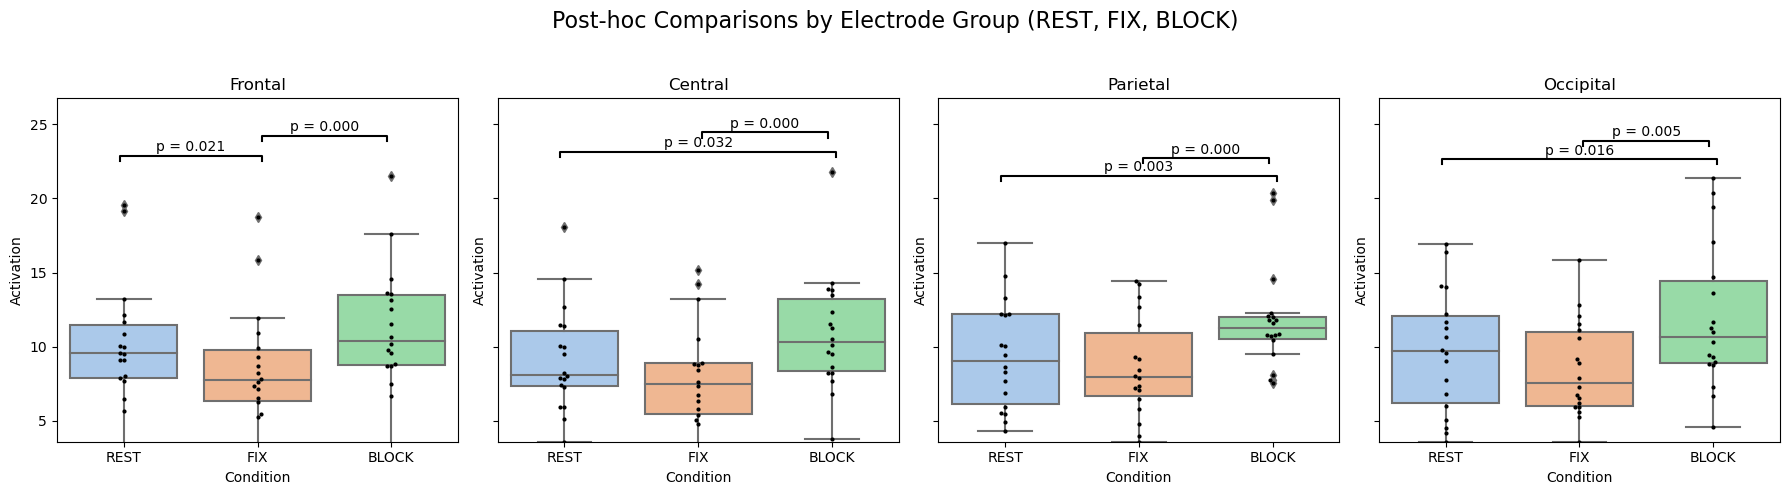

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
import pingouin as pg

#sns.set(style="whitegrid")
fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharey=True)
condition_order = ['REST', 'FIX', 'BLOCK']

for i, group in enumerate(['Frontal', 'Central', 'Parietal', 'Occipital']):
    group_rows = df[df['ElectrodeGroup'] == group]
    complete_subjects = group_rows.groupby('Subject')['Condition'].nunique()
    complete_subjects = complete_subjects[complete_subjects == 3].index
    group_rows = group_rows[group_rows['Subject'].isin(complete_subjects)]

    posthoc_group = pg.pairwise_tests(
        data=group_rows,
        dv='Activation',
        within='Condition',
        subject='Subject',
        parametric=True,
        padjust='fdr_bh'
    )

    ax = axes[i]
    sns.boxplot(data=group_rows, x='Condition', y='Activation', ax=ax, palette='pastel', order=condition_order)
    sns.swarmplot(data=group_rows, x='Condition', y='Activation', ax=ax, color='black', size=3, order=condition_order)
    ax.set_title(f'{group}')

    comparisons = [('REST', 'FIX'), ('REST', 'BLOCK'), ('BLOCK', 'FIX')]
    y_max = group_rows['Activation'].max()
    y_min = group_rows['Activation'].min()
    y_range = y_max - y_min

    # Reserve 30% extra space at the top for significance bars
    ax.set_ylim(y_min, y_max + 0.3 * y_range)

    base = y_max + 0.05 * y_range
    spacing = 0.07 * y_range  # vertical space between bars
    jitter = 0.03  # horizontal offset for vertical lines

    current_bar = 0
    for cond1, cond2 in comparisons:
        row = posthoc_group[
            ((posthoc_group['A'] == cond1) & (posthoc_group['B'] == cond2)) |
            ((posthoc_group['A'] == cond2) & (posthoc_group['B'] == cond1))
        ]
        if not row.empty:
            pval_corr = row['p-corr'].values[0]
            if pval_corr < 0.05:
                x1 = condition_order.index(cond1)
                x2 = condition_order.index(cond2)
                x_center = (x1 + x2) / 2
                y = base + current_bar * spacing

                # Horizontal bracket with jittered vertical lines
                ax.plot([x1 - jitter, x1 - jitter, x2 + jitter, x2 + jitter],
                        [y, y + 0.02 * y_range, y + 0.02 * y_range, y],
                        color='black', linewidth=1.5)

                # Annotated p-value
                ax.text(x_center, y + 0.025 * y_range, f"p = {pval_corr:.3f}", ha='center', va='bottom', fontsize=10)
                current_bar += 1

plt.suptitle('Post-hoc Comparisons by Electrode Group (REST, FIX, BLOCK)', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


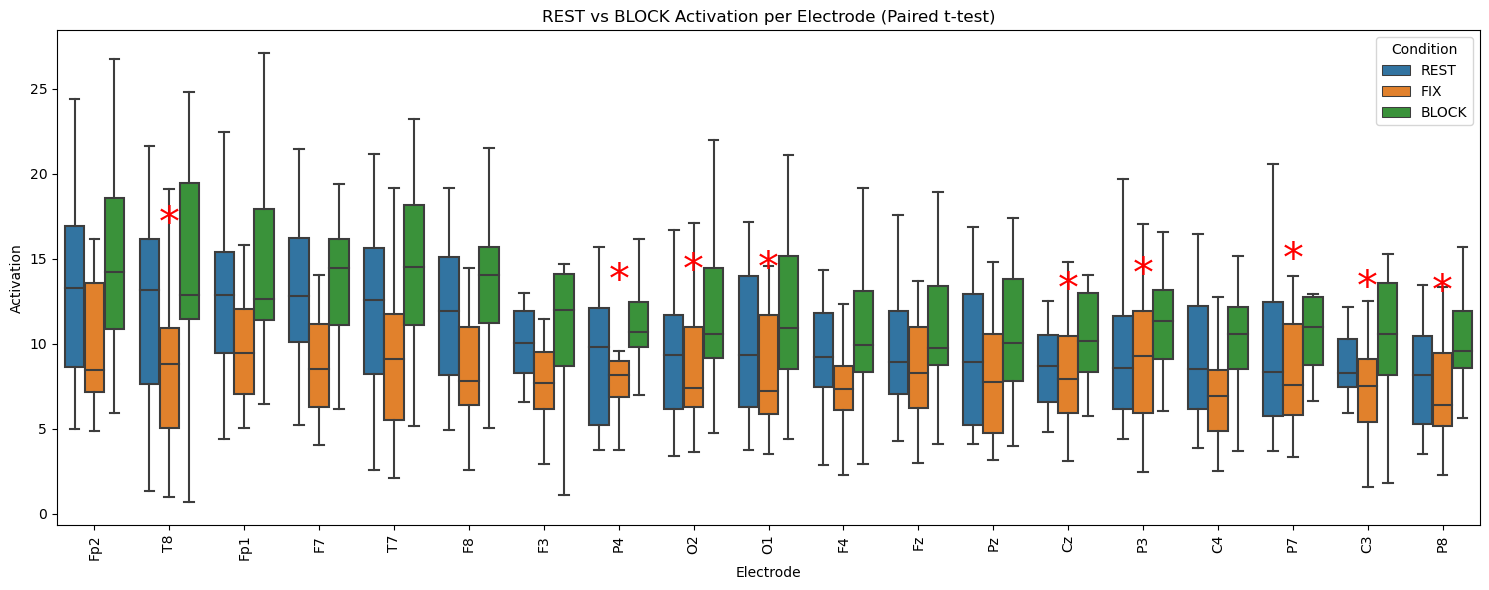

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_rel

#sns.set(style="whitegrid")

# Assuming you already have:
# - rest_all, fix_all, block_all: shape (n_subjects, n_electrodes, n_timepoints)
# - electrodes: list of electrode names

n_electrodes = rest_all.shape[1]
p_values = []
significant = []

# Collect data
data = []
labels = []
electrode_ids = []
mean_activation = []

# To store mean REST per electrode for sorting
rest_means = {}

for e in range(n_electrodes):
    rest_per_subj = rest_all[:, e, :].mean(axis=1)
    fix_per_subj = fix_all[:, e, :].mean(axis=1)
    block_per_subj = block_all[:, e, :].mean(axis=1)

    # Store REST mean for sorting
    rest_means[electrodes[e]] = np.median(rest_per_subj)

    # Store activation data
    data.extend(rest_per_subj)
    labels.extend(['REST'] * len(rest_per_subj))
    electrode_ids.extend([electrodes[e]] * len(rest_per_subj))

    data.extend(fix_per_subj)
    labels.extend(['FIX'] * len(fix_per_subj))
    electrode_ids.extend([electrodes[e]] * len(fix_per_subj))

    data.extend(block_per_subj)
    labels.extend(['BLOCK'] * len(block_per_subj))
    electrode_ids.extend([electrodes[e]] * len(block_per_subj))

    # Paired t-test
    stat, p = ttest_rel(block_per_subj, rest_per_subj)
    p_values.append(p)
    significant.append(p < 0.05)

    # For plotting significance stars
    mean_activation.append(max(np.mean(rest_per_subj), np.mean(block_per_subj)))

# Create DataFrame for seaborn
df = pd.DataFrame({
    'Activation': data,
    'Condition': labels,
    'Electrode': electrode_ids
})

# Sort electrodes by mean REST activation
sorted_electrodes = sorted(rest_means, key=rest_means.get, reverse=True)
electrode_to_pos = {name: i for i, name in enumerate(sorted_electrodes)}

# Plot
plt.figure(figsize=(15, 6))
ax = sns.boxplot(
    data=df,
    x='Electrode',
    y='Activation',
    hue='Condition',
    order=sorted_electrodes,
    showfliers=False
)
plt.title('REST vs BLOCK Activation per Electrode (Paired t-test)')
plt.xticks(rotation=90)

# Add significance stars
for i, sig in enumerate(significant):
    if sig:
        electrode_name = electrodes[i]
        x_pos = electrode_to_pos[electrode_name]
        y = mean_activation[i] + 0.1 * np.abs(mean_activation[i])
        ax.text(x_pos, y, '*', ha='center', va='bottom', color='red', fontsize=30)

plt.tight_layout()
plt.show()


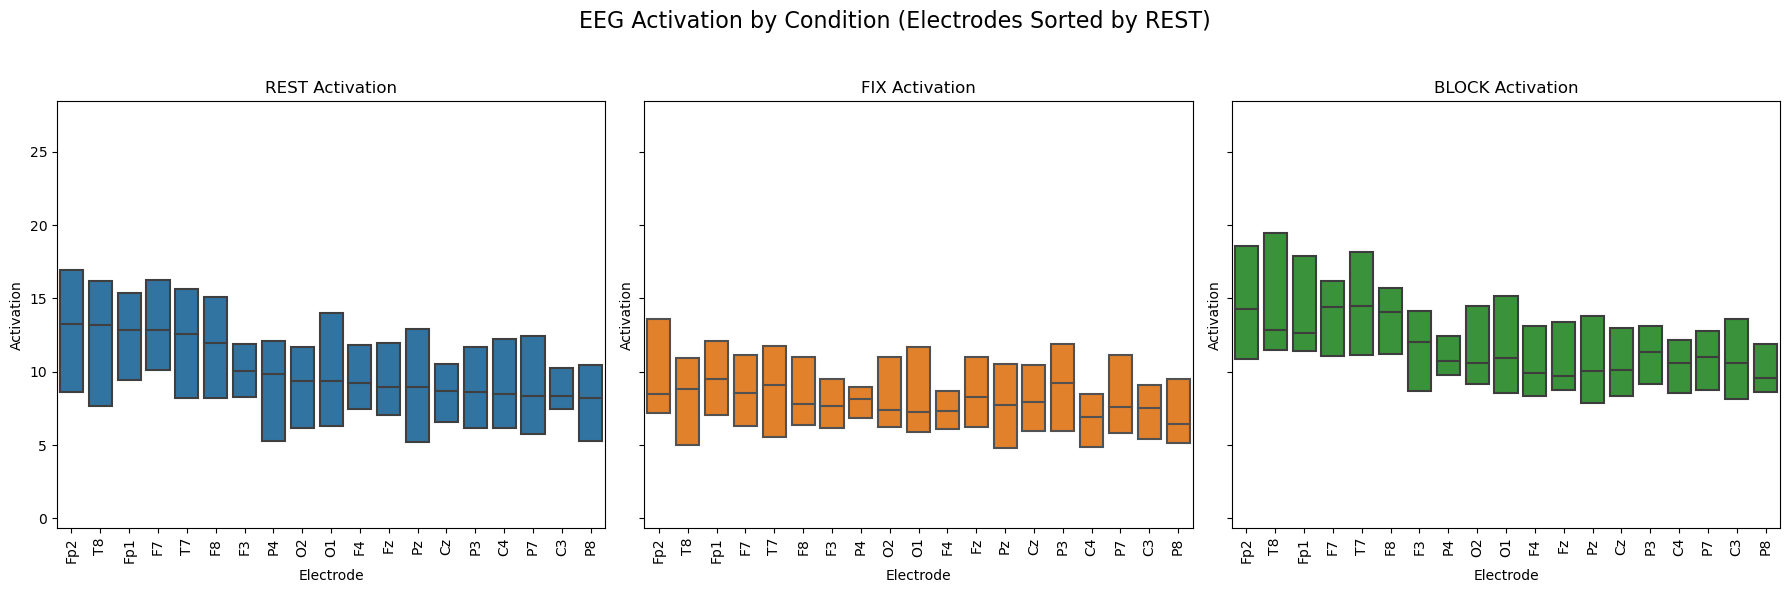

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_rel

#sns.set(style="whitegrid")

# --- Step 1: Compute mean REST per electrode ---
n_electrodes = rest_all.shape[1]
rest_means = {}
data = []
labels = []
electrode_ids = []

for e in range(n_electrodes):
    rest_per_subj = rest_all[:, e, :].mean(axis=1)
    fix_per_subj = fix_all[:, e, :].mean(axis=1)
    block_per_subj = block_all[:, e, :].mean(axis=1)

    rest_means[electrodes[e]] = np.median(rest_per_subj)

    data.extend(rest_per_subj)
    labels.extend(['REST'] * len(rest_per_subj))
    electrode_ids.extend([electrodes[e]] * len(rest_per_subj))

    data.extend(fix_per_subj)
    labels.extend(['FIX'] * len(fix_per_subj))
    electrode_ids.extend([electrodes[e]] * len(fix_per_subj))

    data.extend(block_per_subj)
    labels.extend(['BLOCK'] * len(block_per_subj))
    electrode_ids.extend([electrodes[e]] * len(block_per_subj))

# --- Step 2: Create DataFrame ---
df = pd.DataFrame({
    'Activation': data,
    'Condition': labels,
    'Electrode': electrode_ids
})

# --- Step 3: Sort electrodes based on REST ---
sorted_electrodes = sorted(rest_means, key=rest_means.get, reverse=True)

# --- Step 4: Plot 3 panels ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

conditions = ['REST', 'FIX', 'BLOCK']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # seaborn-like

for ax, cond, color in zip(axes, conditions, colors):
    sns.boxplot(
        data=df[df['Condition'] == cond],
        x='Electrode',
        y='Activation',
        order=sorted_electrodes,
        ax=ax,
        color=color,
        showfliers=False,
        showmeans=False,
        showcaps=False,  # remove end caps
        whiskerprops={'linewidth': 0}
    )

    ax.set_title(f'{cond} Activation')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    #ax.set_ylim(5, 20)

fig.suptitle('EEG Activation by Condition (Electrodes Sorted by REST)', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


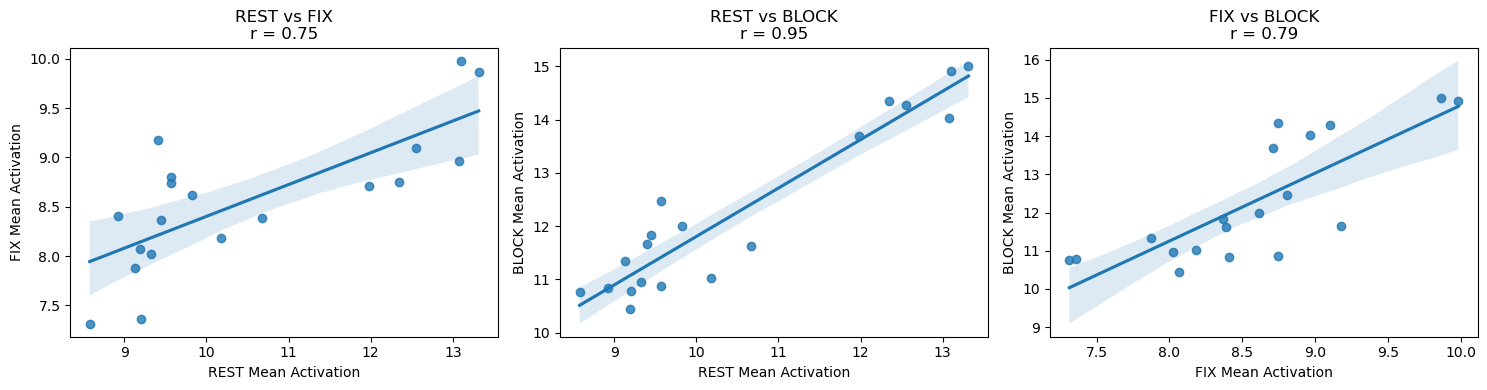

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import seaborn as sns

# Compute mean activation per electrode
rest_means = {electrodes[e]: rest_all[:, e, :].mean() for e in range(len(electrodes))}
fix_means  = {electrodes[e]: fix_all[:, e, :].mean() for e in range(len(electrodes))}
block_means = {electrodes[e]: block_all[:, e, :].mean() for e in range(len(electrodes))}

# Sort by REST means
sorted_electrodes = sorted(rest_means, key=rest_means.get, reverse=True)

# Extract aligned values
rest_vals = np.array([rest_means[e] for e in sorted_electrodes])
fix_vals  = np.array([fix_means[e] for e in sorted_electrodes])
block_vals = np.array([block_means[e] for e in sorted_electrodes])

# Compute correlations
corr_rest_fix, _ = pearsonr(rest_vals, fix_vals)
corr_rest_block, _ = pearsonr(rest_vals, block_vals)
corr_fix_block, _ = pearsonr(fix_vals, block_vals)

# Plot
plt.figure(figsize=(15, 4))

# REST vs FIX
plt.subplot(1, 3, 1)
sns.regplot(x=rest_vals, y=fix_vals)
plt.title(f'REST vs FIX\nr = {corr_rest_fix:.2f}')
plt.xlabel('REST Mean Activation')
plt.ylabel('FIX Mean Activation')

# REST vs BLOCK
plt.subplot(1, 3, 2)
sns.regplot(x=rest_vals, y=block_vals)
plt.title(f'REST vs BLOCK\nr = {corr_rest_block:.2f}')
plt.xlabel('REST Mean Activation')
plt.ylabel('BLOCK Mean Activation')

# FIX vs BLOCK
plt.subplot(1, 3, 3)
sns.regplot(x=fix_vals, y=block_vals)
plt.title(f'FIX vs BLOCK\nr = {corr_fix_block:.2f}')
plt.xlabel('FIX Mean Activation')
plt.ylabel('BLOCK Mean Activation')

plt.tight_layout()
plt.show()


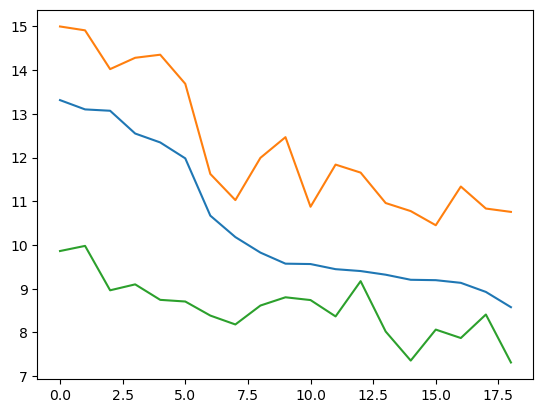

In [18]:
plt.plot(rest_vals)
plt.plot(block_vals)
plt.plot(fix_vals)
plt.show()

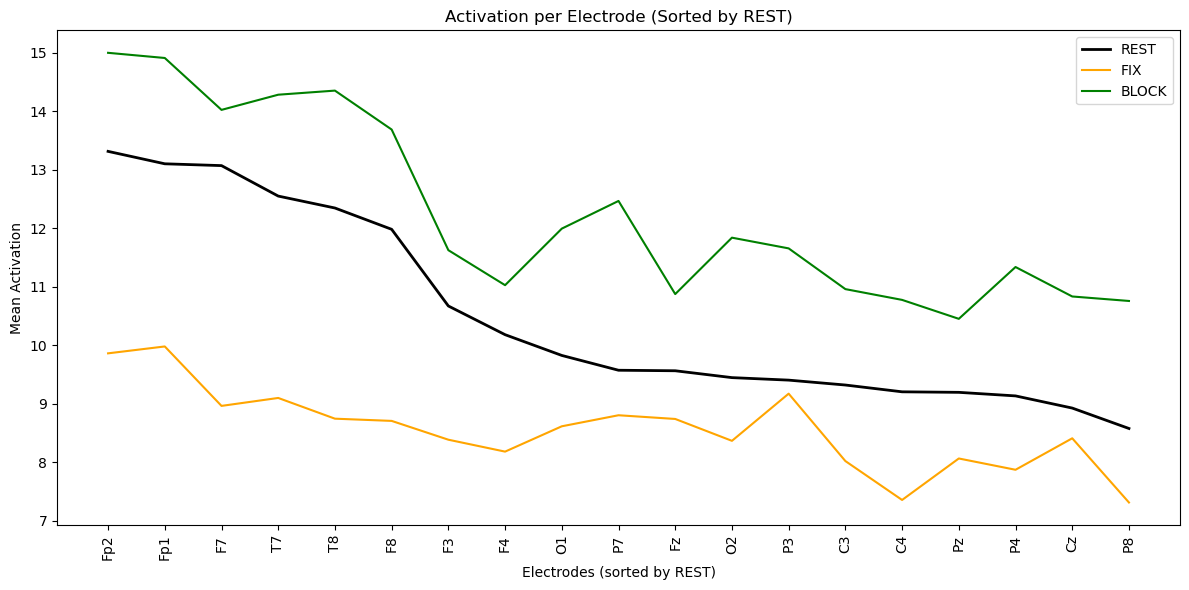

In [19]:
plt.figure(figsize=(12, 6))
x = np.arange(len(sorted_electrodes))

plt.plot(x, rest_vals, label='REST', color='black', linewidth=2)
plt.plot(x, fix_vals, label='FIX', color='orange')
plt.plot(x, block_vals, label='BLOCK', color='green')

plt.xticks(x, sorted_electrodes, rotation=90)
plt.xlabel('Electrodes (sorted by REST)')
plt.ylabel('Mean Activation')
plt.title('Activation per Electrode (Sorted by REST)')
plt.legend()
plt.tight_layout()
plt.show()


In [20]:
from sklearn.metrics import mean_squared_error

rmse_fix = np.sqrt(mean_squared_error(rest_vals, fix_vals))
rmse_block = np.sqrt(mean_squared_error(rest_vals, block_vals))

mae_fix = np.mean(np.abs(rest_vals - fix_vals))
mae_block = np.mean(np.abs(rest_vals - block_vals))

print(f"RMSE FIX vs REST:   {rmse_fix:.4f}")
print(f"RMSE BLOCK vs REST: {rmse_block:.4f}")
print(f"MAE  FIX vs REST:   {mae_fix:.4f}")
print(f"MAE  BLOCK vs REST: {mae_block:.4f}")


RMSE FIX vs REST:   2.2607
RMSE BLOCK vs REST: 1.8369
MAE  FIX vs REST:   1.9327
MAE  BLOCK vs REST: 1.7608


In [21]:
from scipy.stats import ttest_rel

t_fix = []
p_fix = []
t_block = []
p_block = []

for e in range(len(electrodes)):
    rest_subj = rest_all[:, e, :].mean(axis=1)
    fix_subj = fix_all[:, e, :].mean(axis=1)
    block_subj = block_all[:, e, :].mean(axis=1)

    t, p = ttest_rel(fix_subj, rest_subj)
    t_fix.append(t)
    p_fix.append(p)

    t, p = ttest_rel(block_subj, rest_subj)
    t_block.append(t)
    p_block.append(p)

# Count how many are significant
print("FIX vs REST:  ", sum(np.array(p_fix) < 0.05), "/", len(electrodes), "significant electrodes")
print("BLOCK vs REST:", sum(np.array(p_block) < 0.05), "/", len(electrodes), "significant electrodes")


FIX vs REST:   10 / 19 significant electrodes
BLOCK vs REST: 9 / 19 significant electrodes


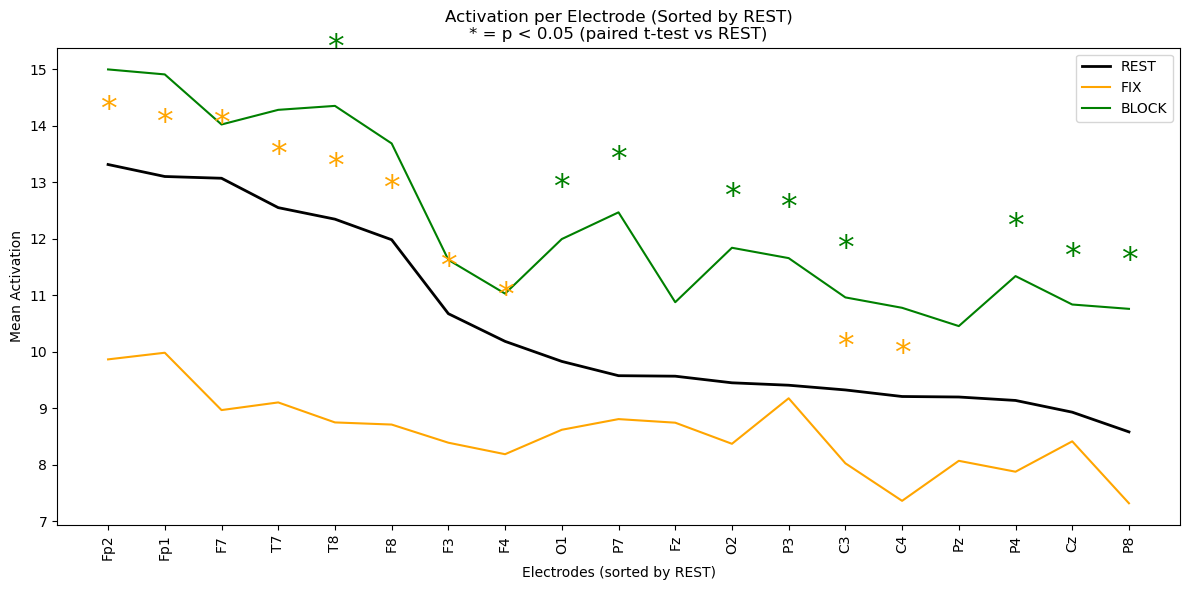

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel

# === 1. Compute mean activation per electrode ===
rest_means = {electrodes[e]: rest_all[:, e, :].mean() for e in range(len(electrodes))}
fix_means  = {electrodes[e]: fix_all[:, e, :].mean() for e in range(len(electrodes))}
block_means = {electrodes[e]: block_all[:, e, :].mean() for e in range(len(electrodes))}

# === 2. Sort electrodes by REST mean ===
sorted_electrodes = sorted(rest_means, key=rest_means.get, reverse=True)

# === 3. Extract sorted mean values ===
rest_vals  = np.array([rest_means[e] for e in sorted_electrodes])
fix_vals   = np.array([fix_means[e] for e in sorted_electrodes])
block_vals = np.array([block_means[e] for e in sorted_electrodes])

# === 4. Paired t-tests: REST vs FIX and REST vs BLOCK ===
p_fix = []
p_block = []
for e in sorted_electrodes:
    idx = electrodes.index(e)
    rest_subj = rest_all[:, idx, :].mean(axis=1)
    fix_subj  = fix_all[:, idx, :].mean(axis=1)
    block_subj = block_all[:, idx, :].mean(axis=1)

    _, p_f = ttest_rel(fix_subj, rest_subj)
    _, p_b = ttest_rel(block_subj, rest_subj)
    
    p_fix.append(p_f)
    p_block.append(p_b)

# === 5. Plot with significance stars ===
plt.figure(figsize=(12, 6))
x = np.arange(len(sorted_electrodes))

# Plot condition lines
plt.plot(x, rest_vals, label='REST', color='black', linewidth=2)
plt.plot(x, fix_vals, label='FIX', color='orange')
plt.plot(x, block_vals, label='BLOCK', color='green')

# Add stars for significant differences
for i, (p_f, p_b) in enumerate(zip(p_fix, p_block)):
    # Star for FIX vs REST
    if p_f < 0.05:
        y = max(rest_vals[i], fix_vals[i]) + 0.05 * np.abs(max(rest_vals[i], fix_vals[i]))
        plt.text(i, y, '*', ha='center', va='bottom', color='orange', fontsize=24)

    # Star for BLOCK vs REST
    if p_b < 0.05:
        y = max(rest_vals[i], block_vals[i]) + 0.05 * np.abs(max(rest_vals[i], block_vals[i]))
        plt.text(i, y, '*', ha='center', va='bottom', color='green', fontsize=24)

# Final plot settings
plt.xticks(x, sorted_electrodes, rotation=90)
plt.xlabel('Electrodes (sorted by REST)')
plt.ylabel('Mean Activation')
plt.title('Activation per Electrode (Sorted by REST)\n* = p < 0.05 (paired t-test vs REST)')
plt.legend()
plt.tight_layout()
plt.show()


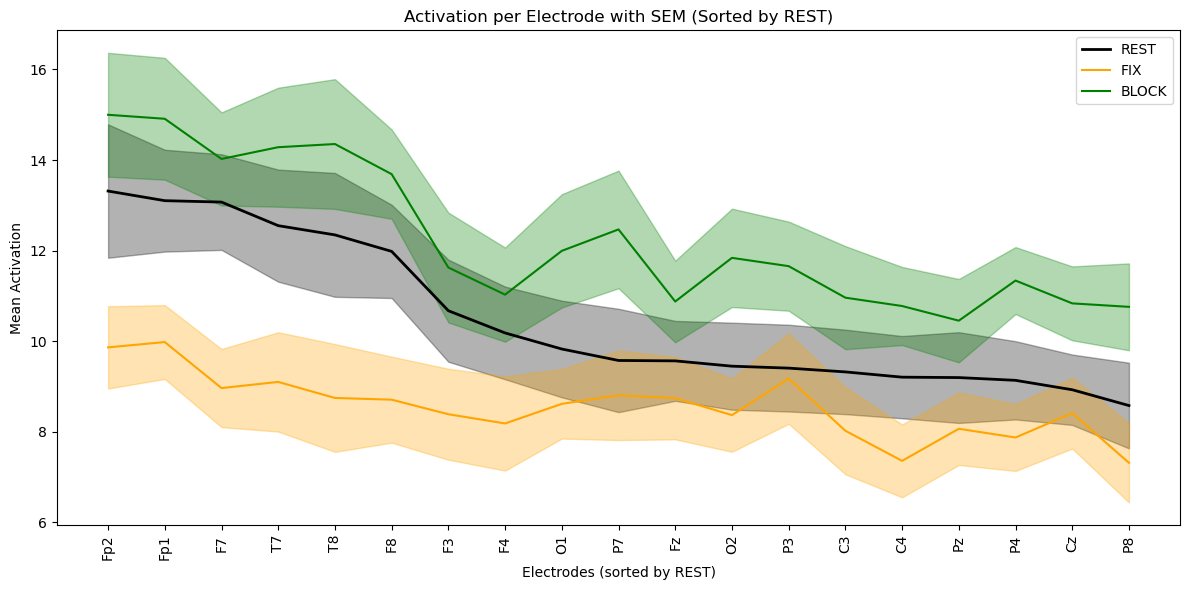

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import sem

# Compute mean and SEM per electrode (aligned with sorted electrodes)
def mean_and_sem(data, electrodes_order):
    means = []
    sems = []
    for e in electrodes_order:
        idx = electrodes.index(e)
        vals = data[:, idx, :].mean(axis=1)  # mean across timepoints per subject
        means.append(np.mean(vals))          # mean across subjects
        sems.append(sem(vals))                # sem across subjects
    return np.array(means), np.array(sems)

# Means and SEMs for each condition, sorted by REST
rest_mean, rest_sem = mean_and_sem(rest_all, sorted_electrodes)
fix_mean, fix_sem = mean_and_sem(fix_all, sorted_electrodes)
block_mean, block_sem = mean_and_sem(block_all, sorted_electrodes)

x = np.arange(len(sorted_electrodes))

plt.figure(figsize=(12, 6))

# Plot REST with SEM shading
plt.plot(x, rest_mean, label='REST', color='black', linewidth=2)
plt.fill_between(x, rest_mean - rest_sem, rest_mean + rest_sem, color='black', alpha=0.3)

# Plot FIX with SEM shading
plt.plot(x, fix_mean, label='FIX', color='orange')
plt.fill_between(x, fix_mean - fix_sem, fix_mean + fix_sem, color='orange', alpha=0.3)

# Plot BLOCK with SEM shading
plt.plot(x, block_mean, label='BLOCK', color='green')
plt.fill_between(x, block_mean - block_sem, block_mean + block_sem, color='green', alpha=0.3)

plt.xticks(x, sorted_electrodes, rotation=90)
plt.xlabel('Electrodes (sorted by REST)')
plt.ylabel('Mean Activation')
plt.title('Activation per Electrode with SEM (Sorted by REST)')
plt.legend()
plt.tight_layout()
plt.show()


In [24]:
rest_mean

array([13.31444558, 13.10198366, 13.07103199, 12.55041973, 12.3464791 ,
       11.98247487, 10.67222404, 10.18193999,  9.82706573,  9.57411204,
        9.56525295,  9.44804475,  9.40522119,  9.32161323,  9.20549599,
        9.19650249,  9.13563966,  8.92774968,  8.57878329])

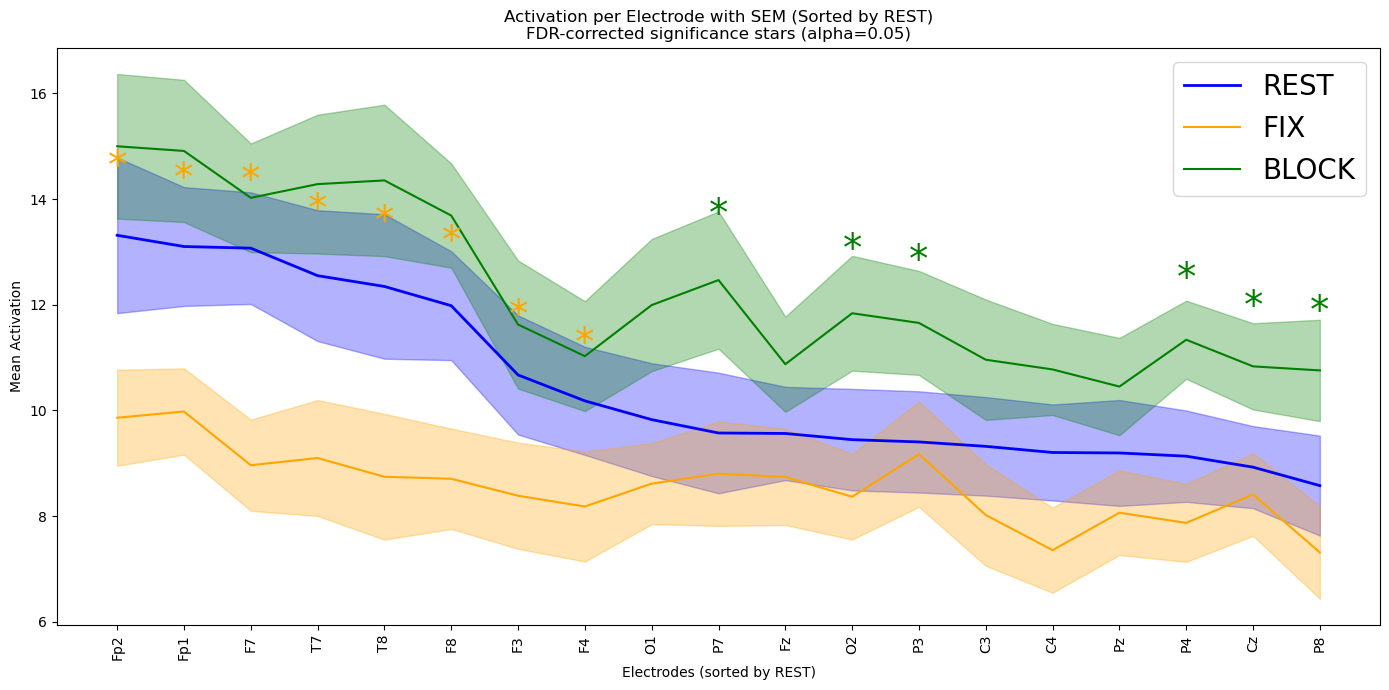

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel, sem
from statsmodels.stats.multitest import multipletests

# === Compute mean and SEM per electrode in sorted order ===
def mean_and_sem(data, electrodes_order):
    means = []
    sems = []
    for e in electrodes_order:
        idx = electrodes.index(e)
        vals = data[:, idx, :].mean(axis=1)  # mean across timepoints per subject
        means.append(np.mean(vals))          # mean across subjects
        sems.append(sem(vals))                # sem across subjects
    return np.array(means), np.array(sems)

# === Prepare sorted electrodes and corresponding means/sems ===
rest_mean, rest_sem = mean_and_sem(rest_all, sorted_electrodes)
fix_mean, fix_sem = mean_and_sem(fix_all, sorted_electrodes)
block_mean, block_sem = mean_and_sem(block_all, sorted_electrodes)

# === Perform paired t-tests REST vs FIX and REST vs BLOCK ===
p_fix = []
p_block = []
for e in sorted_electrodes:
    idx = electrodes.index(e)
    rest_subj = rest_all[:, idx, :].mean(axis=1)
    fix_subj  = fix_all[:, idx, :].mean(axis=1)
    block_subj = block_all[:, idx, :].mean(axis=1)

    _, p_f = ttest_rel(fix_subj, rest_subj)
    _, p_b = ttest_rel(block_subj, rest_subj)
    
    p_fix.append(p_f)
    p_block.append(p_b)

p_fix = np.array(p_fix)
p_block = np.array(p_block)

# === FDR correction (Benjamini-Hochberg) ===
rej_fix, pval_fix_corrected, _, _ = multipletests(p_fix, alpha=0.05, method='fdr_bh')
rej_block, pval_block_corrected, _, _ = multipletests(p_block, alpha=0.05, method='fdr_bh')

sig_fix = rej_fix
sig_block = rej_block

# === Plotting ===
x = np.arange(len(sorted_electrodes))
plt.figure(figsize=(14, 7))

# Plot means and SEM shaded areas
plt.plot(x, rest_mean, label='REST', color='blue', linewidth=2)
plt.fill_between(x, rest_mean - rest_sem, rest_mean + rest_sem, color='blue', alpha=0.3)

plt.plot(x, fix_mean, label='FIX', color='orange')
plt.fill_between(x, fix_mean - fix_sem, fix_mean + fix_sem, color='orange', alpha=0.3)

plt.plot(x, block_mean, label='BLOCK', color='green')
plt.fill_between(x, block_mean - block_sem, block_mean + block_sem, color='green', alpha=0.3)

# Add stars for significant differences after FDR correction
for i in range(len(sorted_electrodes)):
    if sig_fix[i]:
        y = max(rest_mean[i], fix_mean[i]) + 0.07 * abs(max(rest_mean[i], fix_mean[i]))
        plt.text(i, y, '*', ha='center', va='bottom', color='orange', fontsize=28)
    if sig_block[i]:
        y = max(rest_mean[i], block_mean[i]) + 0.07 * abs(max(rest_mean[i], block_mean[i]))
        plt.text(i, y, '*', ha='center', va='bottom', color='green', fontsize=28)

# Labels and formatting
plt.xticks(x, sorted_electrodes, rotation=90)
plt.xlabel('Electrodes (sorted by REST)')
plt.ylabel('Mean Activation')
plt.title('Activation per Electrode with SEM (Sorted by REST)\nFDR-corrected significance stars (alpha=0.05)')
plt.legend(fontsize=20)
plt.tight_layout()
plt.grid(False)
plt.show()


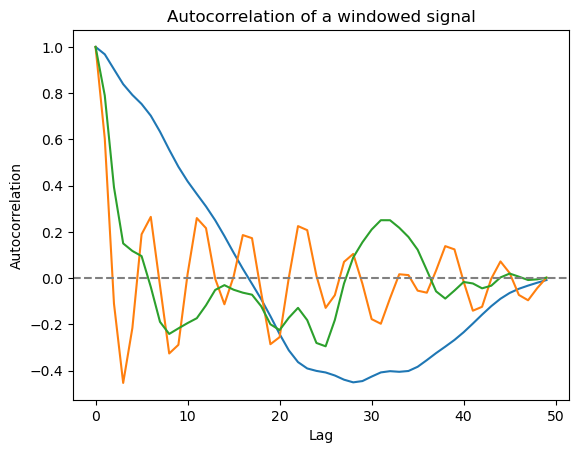

In [26]:
import matplotlib.pyplot as plt


sig_rest = df_rest[elec].dropna().values[:3000]
sig_block = df_block[elec].dropna().values[:3000]
sig_fix = df_fix[elec].dropna().values[:3000]



win_size = 50
step_size = 100
start = 0

signal = sig_rest  # some long signal
window = signal[start:start + win_size]
acf = correlate((window - np.mean(window)) / np.std(window), 
                (window - np.mean(window)) / np.std(window), 
                mode='full')[win_size - 1:] / win_size
plt.plot(acf)

signal = sig_fix  # some long signal
window = signal[start:start + win_size]
acf = correlate((window - np.mean(window)) / np.std(window), 
                (window - np.mean(window)) / np.std(window), 
                mode='full')[win_size - 1:] / win_size
plt.plot(acf)

signal = sig_block  # some long signal
window = signal[start:start + win_size]
acf = correlate((window - np.mean(window)) / np.std(window), 
                (window - np.mean(window)) / np.std(window), 
                mode='full')[win_size - 1:] / win_size
plt.plot(acf)


plt.axhline(0, color='gray', linestyle='--')
plt.title("Autocorrelation of a windowed signal")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.show()


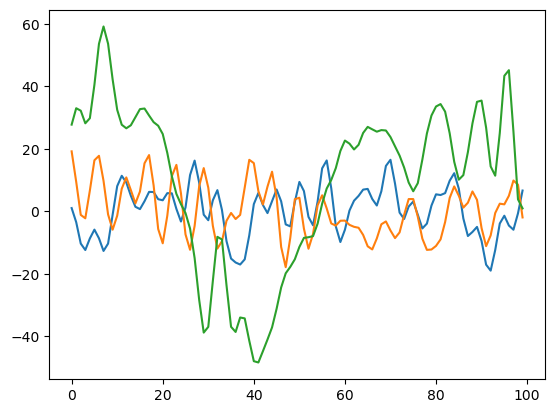

In [27]:
plt.plot(sig_block[:100])
plt.plot(sig_fix[:100])
plt.plot(sig_rest[:100])

plt.show()

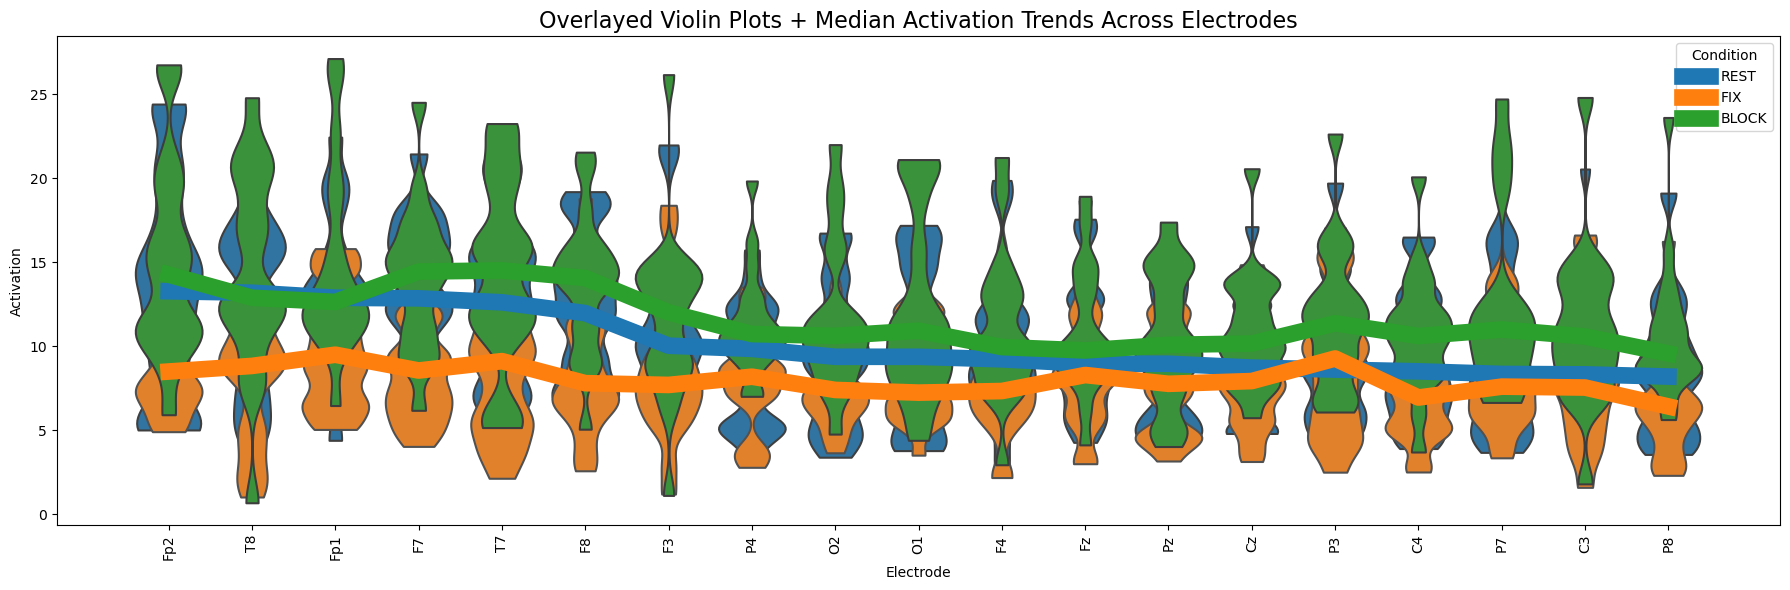

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Step 1: Compute per-electrode activation ---
n_electrodes = rest_all.shape[1]
rest_means = {}
data = []
labels = []
electrodes_list = []

for e in range(n_electrodes):
    rest_per_subj = rest_all[:, e, :].mean(axis=1)
    fix_per_subj = fix_all[:, e, :].mean(axis=1)
    block_per_subj = block_all[:, e, :].mean(axis=1)

    rest_means[electrodes[e]] = np.median(rest_per_subj)

    data.extend(rest_per_subj)
    labels.extend(['REST'] * len(rest_per_subj))
    electrodes_list.extend([electrodes[e]] * len(rest_per_subj))

    data.extend(fix_per_subj)
    labels.extend(['FIX'] * len(fix_per_subj))
    electrodes_list.extend([electrodes[e]] * len(fix_per_subj))

    data.extend(block_per_subj)
    labels.extend(['BLOCK'] * len(block_per_subj))
    electrodes_list.extend([electrodes[e]] * len(block_per_subj))

# --- Step 2: Create DataFrame and sort electrodes ---
df = pd.DataFrame({
    'Activation': data,
    'Condition': labels,
    'Electrode': electrodes_list
})
sorted_electrodes = sorted(rest_means, key=rest_means.get, reverse=True)

# --- Step 3: Plot overlayed violins ---
fig, ax = plt.subplots(figsize=(18, 6))

conditions = ['REST', 'FIX', 'BLOCK']
colors = {'REST': '#1f77b4', 'FIX': '#ff7f0e', 'BLOCK': '#2ca02c'}
alpha = 0.4

for cond in conditions:
    subset = df[df['Condition'] == cond]
    sns.violinplot(
        data=subset,
        x='Electrode',
        y='Activation',
        order=sorted_electrodes,
        bw=0.2,
        cut=0,
        scale='width',
        inner=None,
        color=colors[cond],
        alpha=alpha,
        ax=ax
    )

# --- Step 4: Plot one median line *per condition* across electrodes ---
for cond in conditions:
    medians = []
    for elec in sorted_electrodes:
        vals = df[(df['Electrode'] == elec) & (df['Condition'] == cond)]['Activation']
        if len(vals) > 0:
            medians.append(np.median(vals))
        else:
            medians.append(np.nan)
    x_vals = np.arange(len(sorted_electrodes))
    ax.plot(x_vals, medians, color=colors[cond], label=cond, linewidth=12)

# --- Final formatting ---
ax.set_xticks(np.arange(len(sorted_electrodes)))
ax.set_xticklabels(sorted_electrodes, rotation=90)
ax.set_title('Overlayed Violin Plots + Median Activation Trends Across Electrodes', fontsize=16)
ax.legend(title='Condition')
plt.tight_layout()
plt.show()


In [29]:
fix_vals

array([9.86298333, 9.98064776, 8.96493517, 9.10059534, 8.74643516,
       8.7085226 , 8.38706943, 8.18356366, 8.61627617, 8.80507775,
       8.74165515, 8.36785002, 9.17386204, 8.02228802, 7.35742398,
       8.06628812, 7.87342131, 8.41121225, 7.31424188])

In [30]:
np.save("auc_fix.npy",fix_mean_per_elec)
np.save("auc_block.npy",block_mean_per_elec)
np.save("auc_rest.npy",rest_mean_per_elec)

np.save("auc_rest_all.npy",rest_all)
np.save("auc_fix_all.npy",fix_all)
np.save("auc_block_all.npy",block_all)

In [31]:
fix_vals==fix_mean

array([ True,  True,  True, False,  True,  True, False,  True,  True,
        True,  True,  True,  True,  True,  True,  True, False,  True,
       False])

In [32]:
fix_mean

array([9.86298333, 9.98064776, 8.96493517, 9.10059534, 8.74643516,
       8.7085226 , 8.38706943, 8.18356366, 8.61627617, 8.80507775,
       8.74165515, 8.36785002, 9.17386204, 8.02228802, 7.35742398,
       8.06628812, 7.87342131, 8.41121225, 7.31424188])

In [33]:
rest_mean

array([13.31444558, 13.10198366, 13.07103199, 12.55041973, 12.3464791 ,
       11.98247487, 10.67222404, 10.18193999,  9.82706573,  9.57411204,
        9.56525295,  9.44804475,  9.40522119,  9.32161323,  9.20549599,
        9.19650249,  9.13563966,  8.92774968,  8.57878329])

In [34]:
rest_mean_per_elec

array([ 9.32161323,  9.20549599,  8.92774968, 10.67222404, 10.18193999,
       13.07103199, 11.98247487, 13.10198366, 13.31444558,  9.56525295,
        9.82706573,  9.44804475,  9.40522119,  9.13563966,  9.57411204,
        8.57878329,  9.19650249, 12.55041973, 12.3464791 ])

In [35]:
rest_all.shape

(18, 19, 9)

C:\Users\Peter\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Peter\anaconda3\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\Peter\anaconda3\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\Peter\anaconda3\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a len

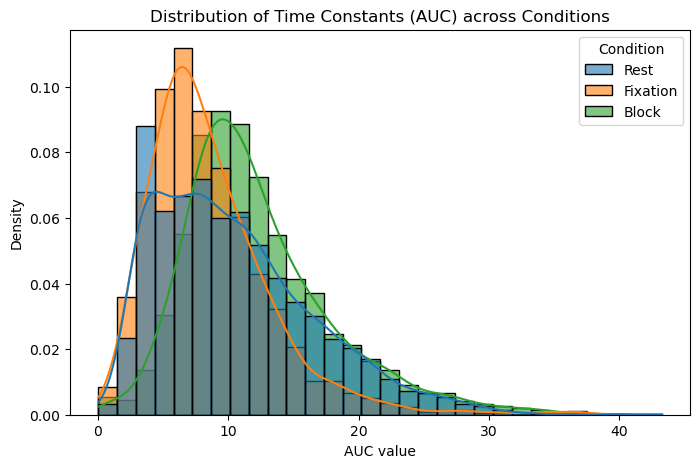

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Flatten electrodes & blocks per subject, then concatenate subjects
def flatten_data(arr):
    return arr.reshape(arr.shape[0], -1)  # (subjects, electrodes * blocks)

rest_flat = flatten_data(rest_all)
fix_flat = flatten_data(fix_all)
block_flat = flatten_data(block_all)

# Combine all data into one DataFrame for seaborn
df = pd.DataFrame({
    'Value': np.concatenate([rest_flat.flatten(), fix_flat.flatten(), block_flat.flatten()]),
    'Condition': ['Rest'] * rest_flat.size + ['Fixation'] * fix_flat.size + ['Block'] * block_flat.size
})

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='Value', hue='Condition', bins=30, kde=True, stat='density', common_norm=False, alpha=0.6)
plt.title("Distribution of Time Constants (AUC) across Conditions")
plt.xlabel("AUC value")
plt.ylabel("Density")
plt.show()


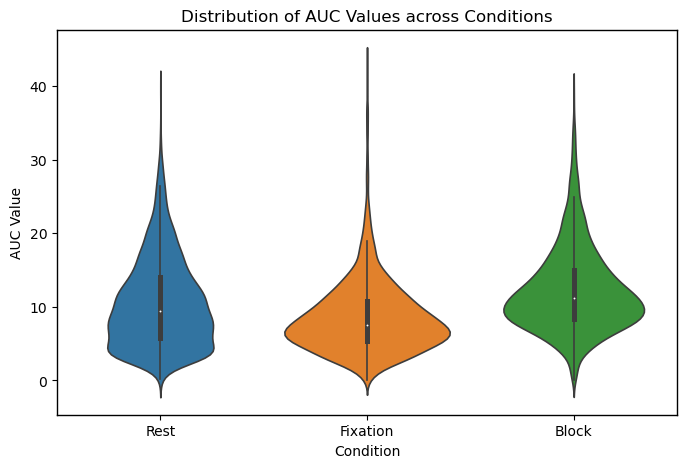

In [37]:
plt.figure(figsize=(8, 5))
sns.violinplot(data=df, x='Condition', y='Value', inner='box', linewidth=1.2,showmedians=True)
plt.title("Distribution of AUC Values across Conditions")
plt.xlabel("Condition")
plt.ylabel("AUC Value")

# Make bounding box black
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_color('black')
    spine.set_linewidth(1)

plt.show()


In [38]:
from scipy.stats import kruskal

# Extract values per condition
rest_vals = df[df['Condition'] == 'Rest']['Value']
fix_vals = df[df['Condition'] == 'Fixation']['Value']
block_vals = df[df['Condition'] == 'Block']['Value']

# Perform Kruskal-Wallis test
stat, p = kruskal(rest_vals, fix_vals, block_vals)
print(f"Kruskal-Wallis H = {stat:.2f}, p = {p:.3g}")

Kruskal-Wallis H = 779.28, p = 6.05e-170


In [39]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

pairs = [
    ('Rest', 'Fixation'),
    ('Rest', 'Block'),
    ('Fixation', 'Block')
]

p_vals = []
for cond1, cond2 in pairs:
    data1 = df[df['Condition'] == cond1]['Value']
    data2 = df[df['Condition'] == cond2]['Value']
    stat, p = mannwhitneyu(data1, data2, alternative='two-sided')
    p_vals.append(p)
    print(f"{cond1} vs {cond2}: U = {stat:.2f}, raw p = {p:.4g}")

# Bonferroni correction
_, p_corrected, _, _ = multipletests(p_vals, method='bonferroni')

print("\nBonferroni-corrected p-values:")
for i, (cond1, cond2) in enumerate(pairs):
    print(f"{cond1} vs {cond2}: corrected p = {p_corrected[i]:.4g}")


Rest vs Fixation: U = 5584102.00, raw p = 5.786e-34
Rest vs Block: U = 3793076.00, raw p = 9.176e-42
Fixation vs Block: U = 2714393.00, raw p = 4.826e-185

Bonferroni-corrected p-values:
Rest vs Fixation: corrected p = 1.736e-33
Rest vs Block: corrected p = 2.753e-41
Fixation vs Block: corrected p = 1.448e-184


C:\Users\Peter\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Peter\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Peter\anaconda3\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


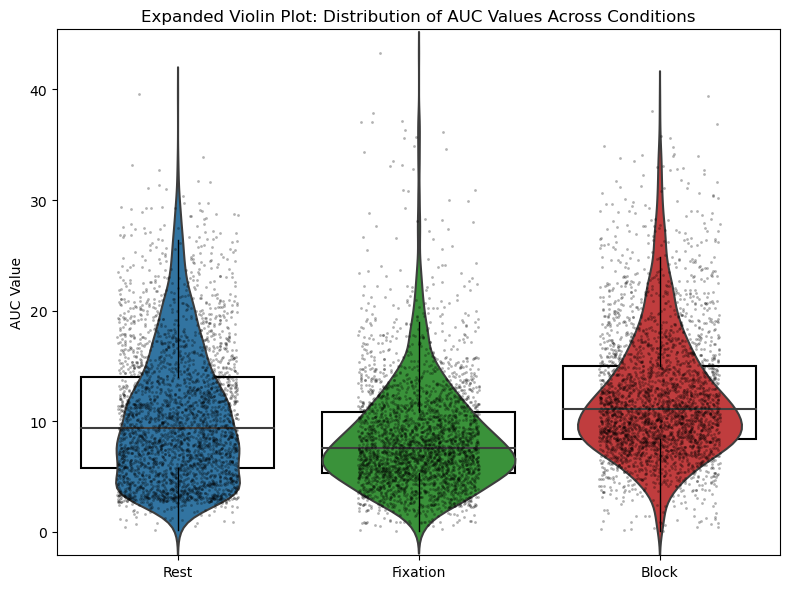

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set custom color palette for consistency
palette = {"Rest": "#1f77b4", "Fixation": "#2ca02c", "Block": "#d62728"}

plt.figure(figsize=(8, 6))

# Violin plot with color per condition
sns.violinplot(data=df, x='Condition', y='Value', inner=None, palette=palette)

# Stripplot for datapoints
sns.stripplot(data=df, x='Condition', y='Value',
              jitter=0.25, size=2, alpha=0.3, color='black')

# Boxplot overlay (outline only)
sns.boxplot(data=df, x='Condition', y='Value',
            showcaps=False,
            boxprops={'facecolor': 'none', 'edgecolor': 'black'},
            whiskerprops={'linewidth': 1, 'color': 'black'},
            showfliers=False)

plt.title("Expanded Violin Plot: Distribution of AUC Values Across Conditions")
plt.ylabel("AUC Value")
plt.xlabel("")
plt.tight_layout()
plt.show()


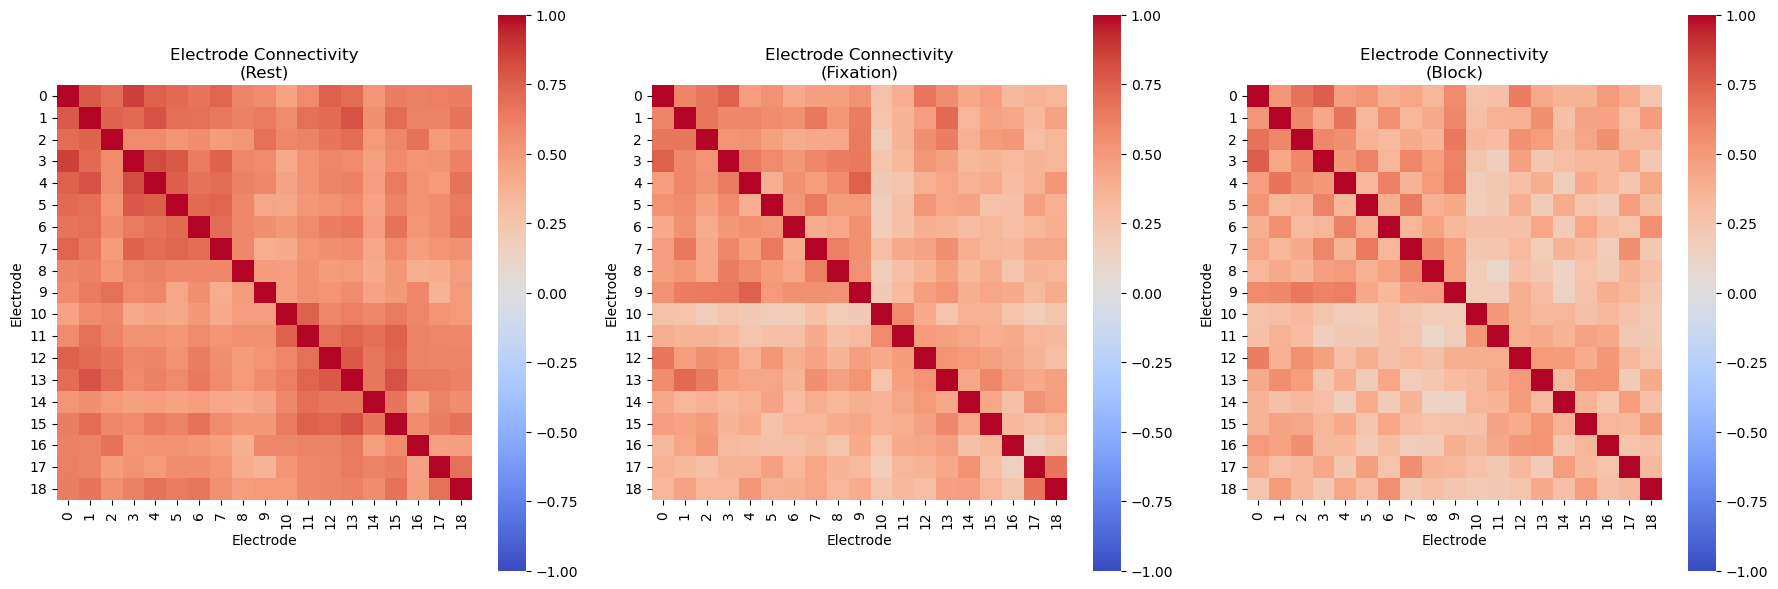

In [41]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Assume your data shapes are (subjects, electrodes, time_points):
# rest_all, fix_all, block_all

def electrode_connectivity_matrix(data):
    """
    Compute electrodes x electrodes correlation matrix for one subject.
    data shape: (electrodes, time_points)
    Returns: electrodes x electrodes correlation matrix
    """
    # Compute Pearson correlation between electrode signals across time
    corr_mat = np.corrcoef(data)
    return corr_mat

def average_connectivity_across_subjects(data_all):
    """
    data_all shape: (subjects, electrodes, time_points)
    Returns average electrodes x electrodes connectivity matrix
    """
    n_subjects = data_all.shape[0]
    n_electrodes = data_all.shape[1]
    avg_corr = np.zeros((n_electrodes, n_electrodes))
    count = 0
    for subj in range(n_subjects):
        subj_data = data_all[subj, :, :]
        if np.isnan(subj_data).any():
            continue
        corr_mat = electrode_connectivity_matrix(subj_data)
        avg_corr += corr_mat
        count += 1
    return avg_corr / max(count, 1)

# Compute average connectivity matrices
rest_conn = average_connectivity_across_subjects(rest_all)
fix_conn = average_connectivity_across_subjects(fix_all)
block_conn = average_connectivity_across_subjects(block_all)

# Plot side-by-side
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

for ax, mat, cond in zip(axs, [rest_conn, fix_conn, block_conn], ['Rest', 'Fixation', 'Block']):
    sns.heatmap(mat, ax=ax, cmap='coolwarm', vmin=-1, vmax=1, square=True, cbar=True)
    ax.set_title(f'Electrode Connectivity\n({cond})')
    ax.set_xlabel('Electrode')
    ax.set_ylabel('Electrode')

plt.tight_layout()
plt.show()
